# 05 — Constantine nuclear data and proton competition

This workbook resolves one narrow gate for the Roman reference design. Constantine is intended to burn

$$^{13}\mathrm{C}+\alpha\rightarrow{}^{16}\mathrm{O}+n.$$

If protons share the hot fuel, they can instead consume the same carbon through

$$^{13}\mathrm{C}+p\rightarrow{}^{14}\mathrm{N}+\gamma.$$

We first reproduce the pinned rate coefficients and the official JINA tabulation. We then compute a **fixed-temperature, fixed-density branching screen**. We do not calculate an implosion, target radius, neutron escape, or a full evolving burn here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.optimize import brentq

from cno_sweep import (
    dataset_path,
    load_builtin_rate,
    load_constantine_rate_validation,
)
from cno_sweep.constants import AVOGADRO
from cno_sweep.io import load_json
from cno_sweep.workbook import reaclib_contribution_rows

pd.set_option("display.precision", 6)
T9_PER_KEV = 0.011_604_518_12
KEV_PER_T9 = 1.0 / T9_PER_KEV
DESIRED = "c13-a-n-o16"
COMPETING = "c13-p-g-n14"

## Frozen inputs and provenance

The calculation uses the project’s pinned subset of the JINA REACLIB default snapshot. A second packaged file contains values transcribed from the official JINA standard-temperature tables. Those tabulated values are a check on our implementation, **not an independent experiment**.

In [2]:
rate_card = load_json(dataset_path("deuterium-loop-rates"))
validation = load_constantine_rate_validation()

provenance = pd.DataFrame([
    {
        "input": "Pinned REACLIB subset",
        "version_or_date": rate_card["upstream_modified"],
        "retrieved": rate_card["retrieved"],
        "source": rate_card["source_url"],
    },
    *[
        {
            "input": reaction_id,
            "version_or_date": source["last_modified"],
            "retrieved": validation["retrieved"],
            "source": source["rate_url"],
        }
        for reaction_id, source in validation["sources"].items()
    ],
])
display(provenance)
display(Markdown(f"Pinned upstream SHA-256: `{rate_card['upstream_sha256']}`"))

,input,version_or_date,retrieved,source
0,Pinned REACLIB subset,2026-06-09,2026-09-02,https://reaclib.jinaweb.org/difout.php?action=...
1,c13-a-n-o16,2015-02-23 10:29:09,2026-09-11,https://reaclib.jinaweb.org/c13%28a%2Cn%29o16/...
2,c13-p-g-n14,2010-06-11 15:14:12,2026-09-11,https://reaclib.jinaweb.org/c13%28p%2Cg%29n14/...


Pinned upstream SHA-256: `bf5bbc8abe45a17bc413d042e149185738d9ed220a6cc91e1219079e80c4da35`

## REACLIB coefficients and additive contributions

A REACLIB reaction rate can be the sum of several seven-coefficient fits. The table below keeps every contribution visible. The reference temperature is $T_9=5$, or $kT=430.867$ keV.

In [3]:
coefficient_rows = []
for reaction_id in [DESIRED, COMPETING]:
    for index, item in enumerate(rate_card["reactions"][reaction_id], start=1):
        coefficient_rows.append({
            "reaction": reaction_id,
            "fit": index,
            "label": item["label"],
            **{f"a{i}": value for i, value in enumerate(item["coefficients"])},
        })
display(pd.DataFrame(coefficient_rows))

reference_keV = 5.0 * KEV_PER_T9
contributions = pd.DataFrame(
    reaclib_contribution_rows(DESIRED, [reference_keV])
    + reaclib_contribution_rows(COMPETING, [reference_keV])
)
display(contributions[["reaction_id", "contribution_index", "source_id", "t9", "rate_na_cm3_mol_s"]])
display(contributions.groupby("reaction_id", as_index=False)["rate_na_cm3_mol_s"].sum())

,reaction,fit,label,a0,a1,a2,a3,a4,a5,a6
0,c13-a-n-o16,1,gl12,79.3008,-0.304890,7.43132,-84.868900,3.650830,-0.148015,37.600800
1,c13-a-n-o16,2,gl12,62.5775,-0.027733,-32.39170,-48.934000,44.184300,-20.874300,2.024940
2,c13-p-g-n14,1,nacrn,18.5155,0.000000,-13.72000,-0.450018,3.708230,-1.705450,-0.666667
3,c13-p-g-n14,2,nacrr,15.1825,-13.554300,0.00000,0.000000,0.000000,0.000000,-1.500000
4,c13-p-g-n14,3,nacrr,13.9637,-5.781470,0.00000,-0.196703,0.142126,-0.023891,-1.500000


,reaction_id,contribution_index,source_id,t9,rate_na_cm3_mol_s
0,c13-a-n-o16,1,gl12,5.0,3.499803e+06
1,c13-a-n-o16,2,gl12,5.0,2.682146e-53
2,c13-p-g-n14,1,nacrn,5.0,9.552816e+00
3,c13-p-g-n14,2,nacrr,5.0,2.332971e+04
4,c13-p-g-n14,3,nacrr,5.0,3.346416e+04


,reaction_id,rate_na_cm3_mol_s
0,c13-a-n-o16,3.499803e+06
1,c13-p-g-n14,5.680343e+04


## Reproduction of the official standard-temperature tables

The relative error here measures transcription/rounding and our implementation—not nuclear-data uncertainty.

In [4]:
validation_rows = []
for reaction_id, points in validation["standard_points"].items():
    rate = load_builtin_rate(reaction_id)
    for point in points:
        temperature_keV = point["t9"] * KEV_PER_T9
        calculated = rate.rate_m3_s(temperature_keV) * AVOGADRO * 1.0e6
        tabulated = point["rate_cm3_mol_s"]
        validation_rows.append({
            "reaction": reaction_id,
            "T9": point["t9"],
            "kT_keV": temperature_keV,
            "JINA_tabulated": tabulated,
            "calculated": calculated,
            "relative_error": calculated / tabulated - 1.0,
        })
validation_table = pd.DataFrame(validation_rows)
display(validation_table)
assert validation_table["relative_error"].abs().max() < 1.0e-5
print(f"Maximum absolute relative error: {validation_table['relative_error'].abs().max():.3e}")

,reaction,T9,kT_keV,JINA_tabulated,calculated,relative_error
0,c13-a-n-o16,0.1,8.617333,4.161588e-14,4.161593e-14,1.269770e-06
1,c13-a-n-o16,0.5,43.086666,7.665867e-02,7.665869e-02,2.351886e-07
2,c13-a-n-o16,1.0,86.173333,2.509077e+02,2.509076e+02,-2.797047e-07
3,c13-a-n-o16,2.0,172.346665,6.066484e+04,6.066479e+04,-8.919962e-07
4,c13-a-n-o16,3.0,258.519998,5.895804e+05,5.895796e+05,-1.306038e-06
5,c13-a-n-o16,5.0,430.866663,3.499810e+06,3.499803e+06,-1.930268e-06
6,c13-a-n-o16,10.0,861.733326,9.744552e+06,9.744521e+06,-3.136737e-06
7,c13-p-g-n14,0.1,8.617333,8.413503e-05,8.413515e-05,1.439927e-06
8,c13-p-g-n14,0.5,43.086666,4.261434e+01,4.261434e+01,-3.252364e-08
9,c13-p-g-n14,1.0,86.173333,3.883479e+03,3.883478e+03,-3.034328e-07


Maximum absolute relative error: 3.137e-06


## Adjudicating the old factor-four discrepancy

An earlier handoff quoted $8.6237\times10^5\;\mathrm{cm^3\,mol^{-1}\,s^{-1}}$ for $^{13}$C$(\alpha,n)$ at $T_9=5$. We compare that number to the complete additive fit and ask at what temperature the complete fit actually equals the quoted value.

In [5]:
quoted_old = 8.6237e5
desired_rate = load_builtin_rate(DESIRED)
implemented_t9_5 = desired_rate.rate_m3_s(reference_keV) * AVOGADRO * 1.0e6

def desired_na_at_t9(t9):
    return desired_rate.rate_m3_s(t9 * KEV_PER_T9) * AVOGADRO * 1.0e6

equivalent_t9 = brentq(lambda t9: desired_na_at_t9(t9) - quoted_old, 3.0, 5.0)
discrepancy = pd.DataFrame([
    {
        "quantity": "Complete gl12 rate at T9=5",
        "value": implemented_t9_5,
        "units": "cm^3 mol^-1 s^-1",
    },
    {"quantity": "Earlier quoted number", "value": quoted_old, "units": "cm^3 mol^-1 s^-1"},
    {"quantity": "Ratio: correct T9=5 / quote", "value": implemented_t9_5 / quoted_old, "units": "dimensionless"},
    {"quantity": "T9 where gl12 equals quote", "value": equivalent_t9, "units": "GK"},
    {"quantity": "kT where gl12 equals quote", "value": equivalent_t9 * KEV_PER_T9, "units": "keV"},
])
display(discrepancy)

,quantity,value,units
0,Complete gl12 rate at T9=5,3.499803e+06,cm^3 mol^-1 s^-1
1,Earlier quoted number,8.623700e+05,cm^3 mol^-1 s^-1
2,Ratio: correct T9=5 / quote,4.058355e+00,dimensionless
3,T9 where gl12 equals quote,3.271153e+00,GK
4,kT where gl12 equals quote,2.818862e+02,keV


**Decision:** use the full pinned `gl12` sum, $3.4998\times10^6\;\mathrm{cm^3\,mol^{-1}\,s^{-1}}$ at $T_9=5$. The earlier $8.6237\times10^5$ number is reproduced near $T_9=3.27$, so it is consistent with a temperature/quotation mix-up. This closes the implementation discrepancy. It does **not** close the separate uncertainty about applying an astrophysical fit at very high temperature; that remains a sensitivity input for the eventual conservative route.

## Rate comparison over the relevant temperature screen

Both rates below are per reacting pair. Density and mixture enter in the next section.

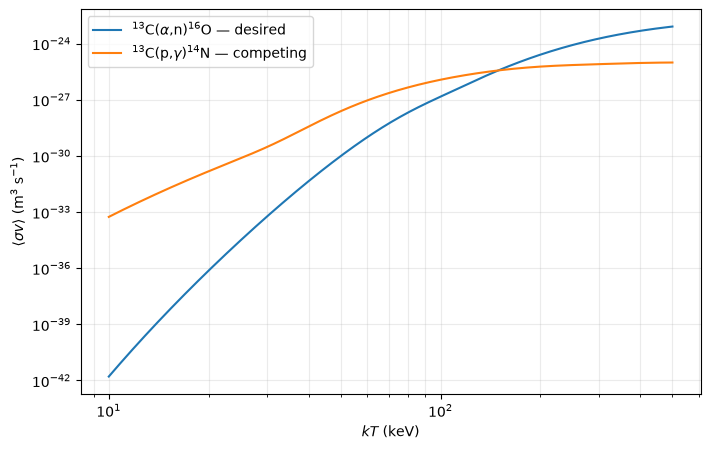

In [6]:
temperature_grid_keV = np.geomspace(10.0, 500.0, 500)
rate_an = np.array([load_builtin_rate(DESIRED).rate_m3_s(t) for t in temperature_grid_keV])
rate_pg = np.array([load_builtin_rate(COMPETING).rate_m3_s(t) for t in temperature_grid_keV])

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(temperature_grid_keV, rate_an, label=r"$^{13}$C($\alpha$,n)$^{16}$O — desired")
ax.loglog(temperature_grid_keV, rate_pg, label=r"$^{13}$C(p,$\gamma$)$^{14}$N — competing")
ax.set(xlabel=r"$kT$ (keV)", ylabel=r"$\langle\sigma v\rangle$ (m$^3$ s$^{-1}$)")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

## Fixed-state branching screen

For one $^{13}$C nucleus in a plasma whose alpha and proton densities are treated as reservoirs, the instantaneous destruction rates are

$$\lambda_{\alpha n}=n_\alpha\langle\sigma v\rangle_{\alpha n},\qquad \lambda_{p\gamma}=n_p\langle\sigma v\rangle_{p\gamma}.$$

Writing $r=n_p/n_\alpha$, the probability that its next destruction follows the desired branch is

$$B_{\alpha n}=\frac{1}{1+r\langle\sigma v\rangle_{p\gamma}/\langle\sigma v\rangle_{\alpha n}}.$$

This is an instantaneous screen. A real shot changes temperature, density, and abundances, so the eventual workbook must integrate both channels along the achieved trajectory.

,n_p/n_alpha,0.1,1.0,3.0,10.0
kT_keV,T9,,,,
50.000000,0.580226,0.038404,0.003978,0.001330,0.000399
100.000000,1.160452,0.555478,0.111080,0.039988,0.012342
150.000000,1.740678,0.910918,0.505579,0.254207,0.092770
200.000000,2.320904,0.977527,0.813078,0.591827,0.303127
250.000000,2.901130,0.991560,0.921557,0.796584,0.540190
300.000000,3.481355,0.995713,0.958726,0.885619,0.699051
430.866663,5.000000,0.998380,0.984029,0.953569,0.860360


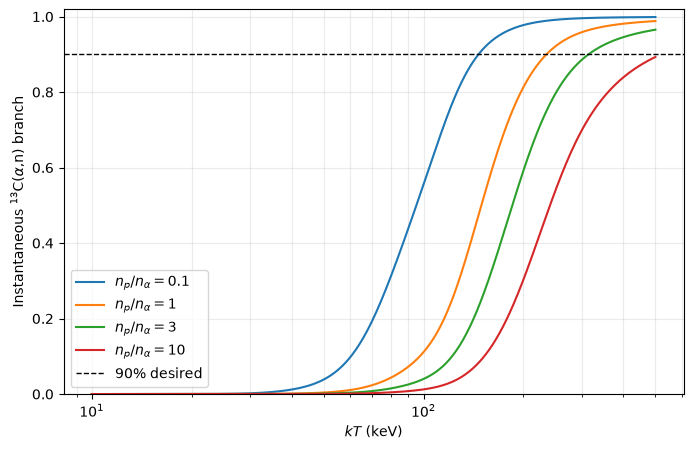

In [7]:
def desired_branch_fraction(temperature_keV, proton_to_alpha):
    k_an = load_builtin_rate(DESIRED).rate_m3_s(float(temperature_keV))
    k_pg = load_builtin_rate(COMPETING).rate_m3_s(float(temperature_keV))
    return 1.0 / (1.0 + proton_to_alpha * k_pg / k_an)

sample_temperatures = [50.0, 100.0, 150.0, 200.0, 250.0, 300.0, reference_keV]
mixture_ratios = [0.1, 1.0, 3.0, 10.0]
branch_rows = []
for temperature_keV in sample_temperatures:
    for proton_to_alpha in mixture_ratios:
        branch_rows.append({
            "kT_keV": temperature_keV,
            "T9": temperature_keV * T9_PER_KEV,
            "n_p/n_alpha": proton_to_alpha,
            "desired_branch": desired_branch_fraction(temperature_keV, proton_to_alpha),
        })
branch_table = pd.DataFrame(branch_rows)
display(branch_table.pivot(index=["kT_keV", "T9"], columns="n_p/n_alpha", values="desired_branch"))

fig, ax = plt.subplots(figsize=(8, 5))
for ratio in mixture_ratios:
    branch = [desired_branch_fraction(t, ratio) for t in temperature_grid_keV]
    ax.semilogx(temperature_grid_keV, branch, label=fr"$n_p/n_\alpha={ratio:g}$")
ax.axhline(0.9, color="black", linestyle="--", linewidth=1, label="90% desired")
ax.set(xlabel=r"$kT$ (keV)", ylabel=r"Instantaneous $^{13}$C($\alpha$,n) branch", ylim=(0, 1.02))
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

## How proton-free must Constantine be?

Solving the branch expression for $r=n_p/n_\alpha$ gives the largest proton ratio compatible with a chosen instantaneous desired-branch target:

$$r_{\max}=\left(\frac{1}{B_{\alpha n}}-1\right)\frac{\langle\sigma v\rangle_{\alpha n}}{\langle\sigma v\rangle_{p\gamma}}.$$

In [8]:
threshold_rows = []
for temperature_keV in sample_temperatures:
    k_an = load_builtin_rate(DESIRED).rate_m3_s(temperature_keV)
    k_pg = load_builtin_rate(COMPETING).rate_m3_s(temperature_keV)
    for target_branch in [0.90, 0.95, 0.99]:
        threshold_rows.append({
            "kT_keV": temperature_keV,
            "target_desired_branch": target_branch,
            "maximum_n_p/n_alpha": (1.0 / target_branch - 1.0) * k_an / k_pg,
        })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.pivot(index="kT_keV", columns="target_desired_branch", values="maximum_n_p/n_alpha"))

target_desired_branch,0.90,0.95,0.99
kT_keV,,,
50.000000,0.000444,0.000210,0.000040
100.000000,0.013885,0.006577,0.001262
150.000000,0.113618,0.053819,0.010329
200.000000,0.483314,0.228938,0.043938
250.000000,1.305344,0.618321,0.118668
300.000000,2.580916,1.222539,0.234629
430.866663,6.845837,3.242765,0.622349


## Conclusions and handoff to later workbooks

1. **Rate implementation:** the pinned full `gl12` sum reproduces the official JINA table. At $T_9=5$ it is about $3.4998\times10^6\;\mathrm{cm^3\,mol^{-1}\,s^{-1}}$.
2. **Old discrepancy:** the earlier $8.6237\times10^5$ value belongs near $T_9=3.27$, not $T_9=5$. The factor-four implementation dispute is closed.
3. **Physical-data caution:** exact reproduction of a fit is not experimental validation of that fit at every engineered-fusion temperature. A conservative route should expose rate multipliers or alternative evaluations.
4. **Topology implication:** proton contamination is catastrophic in cooler Constantine states and much less severe at the hot end. Therefore proton-free Constantine remains the conservative reference recipe, but mixed fuel is not rejected solely by the $T_9=5$ instantaneous branch.
5. **Next calculation:** feed both rates into a coupled-depletion ODE along the temperature/density history supplied by the implosion workbook. Only that calculation can turn this screen into an achieved neutron yield.

Reviewer choices to carry forward: retain proton-free Constantine as the reference; run a likely and conservative multiplier on $^{13}$C$(\alpha,n)$; and do not infer target radii from this workbook.